In [1]:
import sys
sys.dont_write_bytecode = True
%load_ext autoreload
%autoreload 1
%aimport classify_dice
import classify_dice
from ultralytics import YOLO
import sklearn
import cv2
from matplotlib import pyplot as plt
import numpy as np
import einops

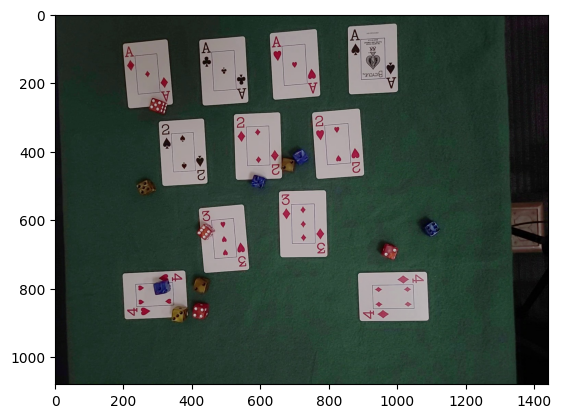

In [2]:
obb_model = YOLO("model/rdg_obb/weights/best.pt")
# obb_model = YOLO("model/rdg_obb6/weights/best.pt")

example_frame = "data/frames/frame_0214.jpg"
# example_frame = "data/additional_photos/raw/20251208_171417.jpg"
# example_frame = "data/additional_photos/raw/20251208_182235.jpg"
img = cv2.imread(example_frame)
classify_dice.imshow(img)

In [3]:
res = obb_model(img, task='obb')[0]
res


0: 384x512 12 dies, 4 aces, 3 twos, 2 threes, 2 fours, 56.6ms
Speed: 14.9ms preprocess, 56.6ms inference, 47.4ms postprocess per image at shape (1, 3, 384, 512)


ultralytics.engine.results.Results object with attributes:

boxes: None
keypoints: None
masks: None
names: {0: 'die', 1: 'ace', 2: 'two', 3: 'three', 4: 'four'}
obb: ultralytics.engine.results.OBB object
orig_img: array([[[20, 25, 23],
        [21, 26, 24],
        [29, 33, 28],
        ...,
        [33, 26, 31],
        [28, 21, 24],
        [21, 14, 17]],

       [[18, 23, 21],
        [19, 24, 22],
        [28, 32, 27],
        ...,
        [32, 25, 30],
        [28, 21, 24],
        [23, 16, 19]],

       [[17, 22, 20],
        [17, 22, 20],
        [27, 31, 26],
        ...,
        [30, 23, 28],
        [27, 20, 25],
        [24, 17, 22]],

       ...,

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11, 11],
        [11, 11, 11],
        ...,
        [ 2,  2,  2],
        [ 2,  2,  2],
        [ 2,  2,  2]],

       [[11, 11, 11],
        [11, 11,

In [4]:
res[0].obb

ultralytics.engine.results.OBB object with attributes:

cls: tensor([3.], device='cuda:0')
conf: tensor([0.9655], device='cuda:0')
data: tensor([[493.3746, 653.5643, 200.1789, 129.4977,   1.5234,   0.9655,   3.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 1440)
shape: torch.Size([1, 7])
xywhr: tensor([[493.3746, 653.5643, 200.1789, 129.4977,   1.5234]], device='cuda:0')
xyxy: tensor([[423.9603, 550.5220, 562.7888, 756.6066]], device='cuda:0')
xyxyxyxy: tensor([[[433.4363, 756.6066],
         [562.7888, 750.4764],
         [553.3128, 550.5220],
         [423.9603, 556.6521]]], device='cuda:0')
xyxyxyxyn: tensor([[[0.3010, 0.7006],
         [0.3908, 0.6949],
         [0.3842, 0.5097],
         [0.2944, 0.5154]]], device='cuda:0')

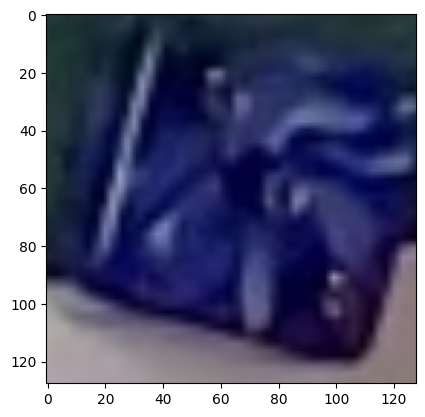

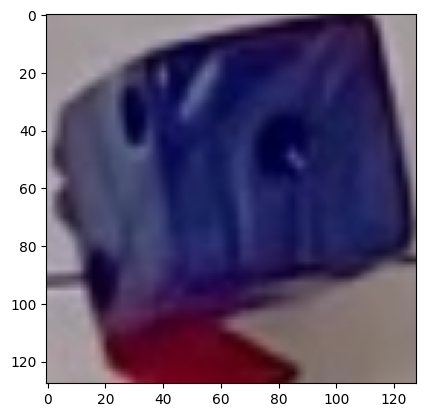

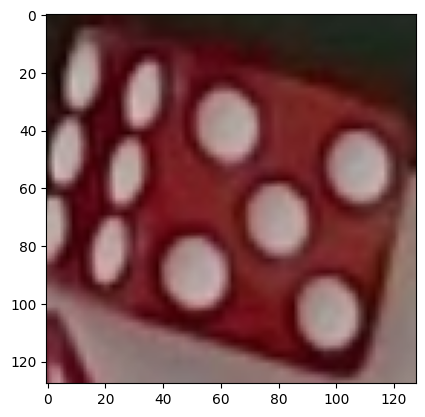

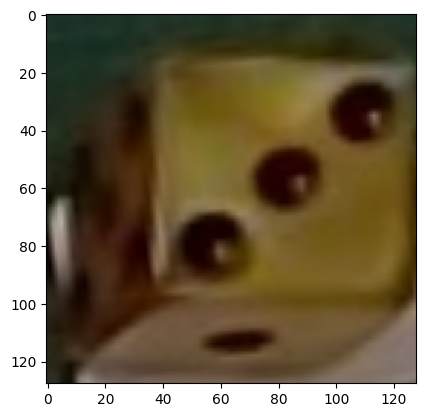

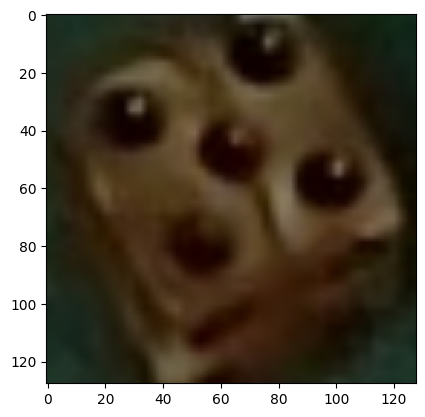

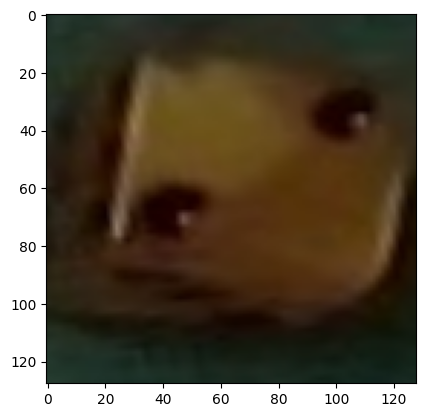

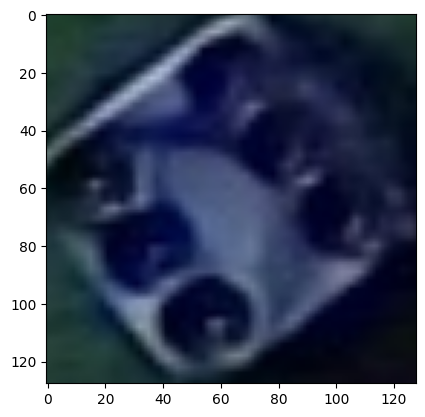

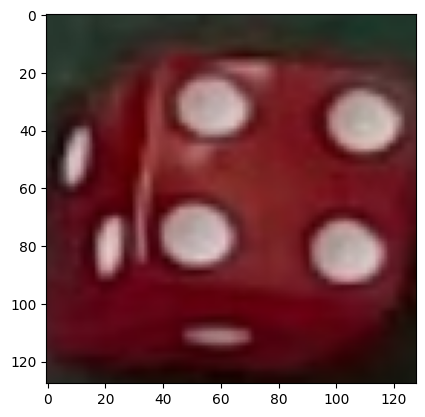

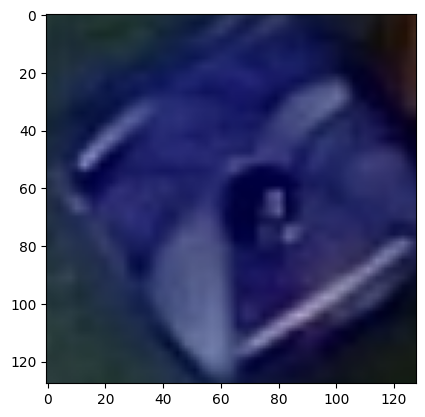

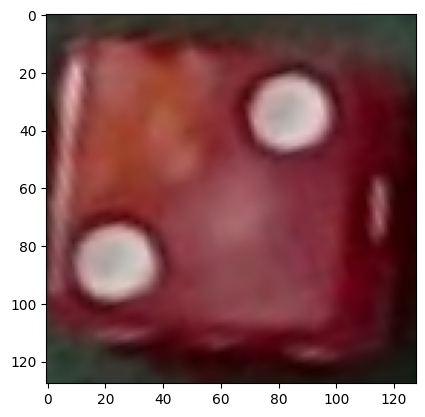

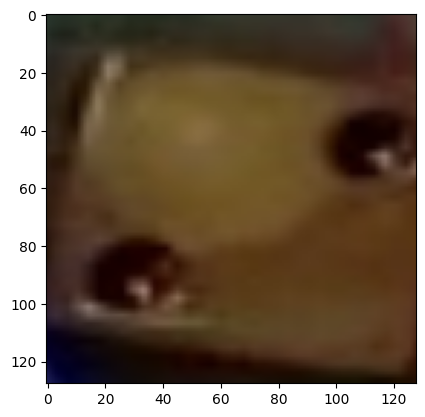

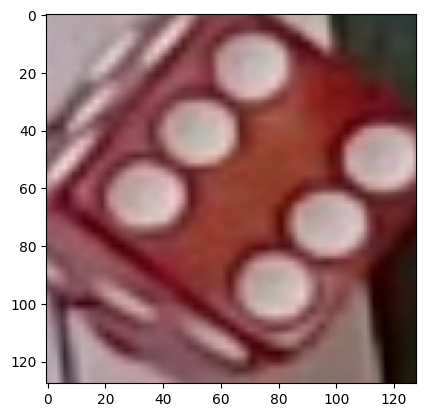

In [5]:
dice_cropped = classify_dice.batch_crop_dice(img, res)

for die_idx in range(dice_cropped.shape[0]):
    plt.figure()
    classify_dice.imshow(dice_cropped[die_idx,:,:,:])

In [6]:
k_means,palette = classify_dice.kmeans_color(dice_cropped, k=16)

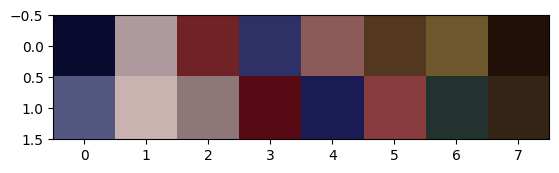

In [7]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

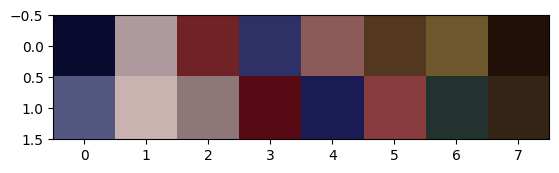

In [8]:
classify_dice.imshow(einops.rearrange(palette, "(h w) C -> h w C", w=8))

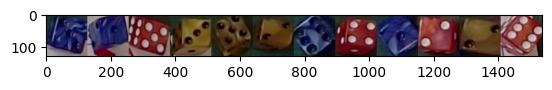

In [9]:
classify_dice.imshow(einops.rearrange(dice_cropped, "N H W C-> H (N W) C"))

<Figure size 640x480 with 0 Axes>

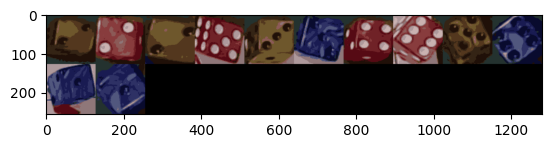

(973, 128, 128, 3)


<Figure size 640x480 with 0 Axes>

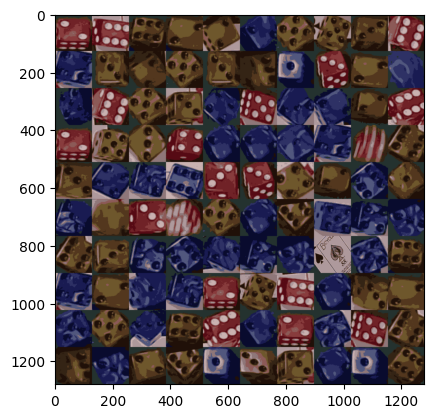

In [10]:
# recolor dice using this limited palette


classes,posterized = classify_dice.posterize(dice_cropped, k_means, palette)
sample_idxs = np.random.permutation(posterized.shape[0])[:100]
plt.figure()
# classify_dice.imshow(einops.rearrange(posterized[sample_idxs,...], "(N x) H W C -> (N H) (x W) C", x=4))
classify_dice.show_imgs_grid(posterized[sample_idxs,...], width=10)
plt.show()

# all_dice = classify_dice.generate_dice_dataset(obb_model)
all_dice = np.load('data/dice/all_dice.npz')['arr_0']
print(all_dice.shape)
_,all_dice_posterized = classify_dice.posterize(all_dice, k_means, palette)
sample_idxs = np.random.permutation(all_dice_posterized.shape[0])[:100]
plt.figure()
classify_dice.show_imgs_grid(all_dice_posterized[sample_idxs,...], width=10)
plt.show()


In [11]:
limgs,lids,lplayers,lvalues = classify_dice.load_labeled_dice()

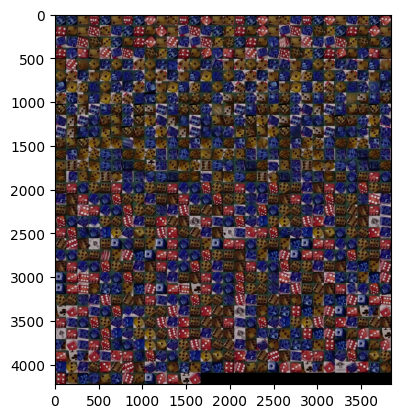

In [12]:
classify_dice.show_imgs_grid(all_dice,width=30)

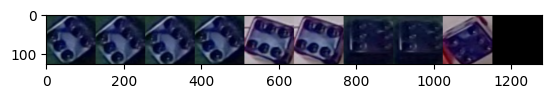

In [13]:
mask=(lplayers==2)&(lvalues==6)
classify_dice.show_imgs_grid(limgs[mask], width=10)

lids[bad_idx]=np.int64(938)


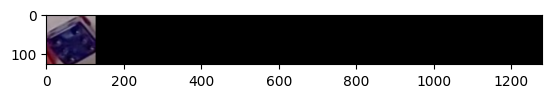

In [14]:
bad_idx = np.argwhere(np.cumsum(mask)==9)[0,0]
print(f"{lids[bad_idx]=}")
classify_dice.show_imgs_grid(limgs[[bad_idx],:,:,:])

np.int64(760)

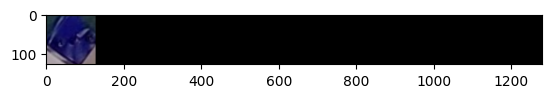

In [15]:
classify_dice.show_imgs_grid(limgs[[154],:,:,:])
lids[154]

In [16]:
# np.savez_compressed('data/dice/all_dice.npz', all_dice.astype(np.uint8))

In [17]:
# classify_dice.write_dice()

In [18]:
# def to_histogram(imgs):
#     N,H,W,C = imgs
classes,posterized = classify_dice.posterize(limgs, k_means, palette)


In [19]:
flattened_classes = einops.rearrange(classes, "N H W -> N (H W)")

histograms = np.zeros((flattened_classes.shape[0], palette.shape[0]))
for i in range(flattened_classes.shape[0]):
    histograms[i,:] = np.bincount(flattened_classes[i,:], minlength=palette.shape[0])
    histograms[i,:] /= histograms[i,:].sum()
# einops.reduce()
# np.bincount(flattened_classes, minlength=16)

# sklearn.d

histograms


array([[          0,    0.060669,     0.18365, ...,    0.036804,    0.091064,    0.068359],
       [          0,           0,           0, ...,           0,     0.12213,     0.12616],
       [          0,     0.05835,     0.14581, ...,    0.034729,    0.098633,    0.074585],
       ...,
       [          0,    0.073364,     0.41638, ...,     0.11444,    0.001709,    0.010315],
       [  0.0097656,   0.0022583,           0, ...,  0.00018311,    0.012146,     0.12756],
       [   0.039307,     0.13629,     0.40497, ...,     0.12952,   0.0031738,   0.0062256]], shape=(186, 16))

In [20]:
pca = sklearn.decomposition.PCA(n_components=2, whiten=True, random_state=1337)
hist_pca = pca.fit_transform(histograms)


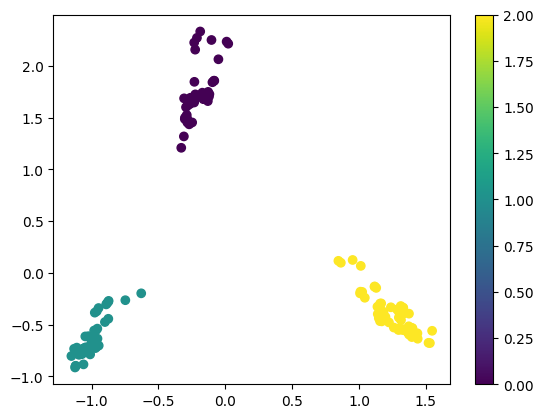

In [21]:
plt.scatter(hist_pca[:,0], hist_pca[:,1], c=lplayers)
plt.colorbar()

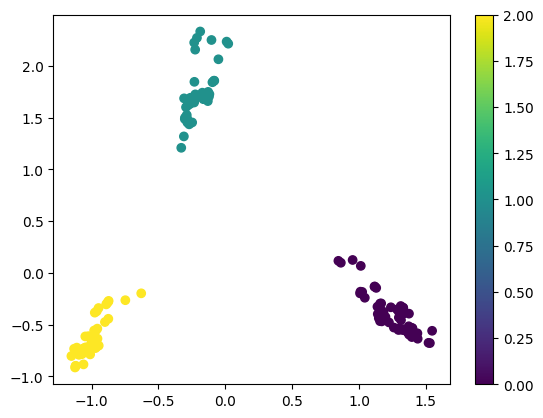

In [ ]:
_,cluster_predictions = classify_dice.kmeans_cluster_players(histograms, n_players=3)
plt.scatter(hist_pca[:,0], hist_pca[:,1], c=cluster_predictions)
plt.colorbar()

pst.shape=(1, 1080, 1440, 3)


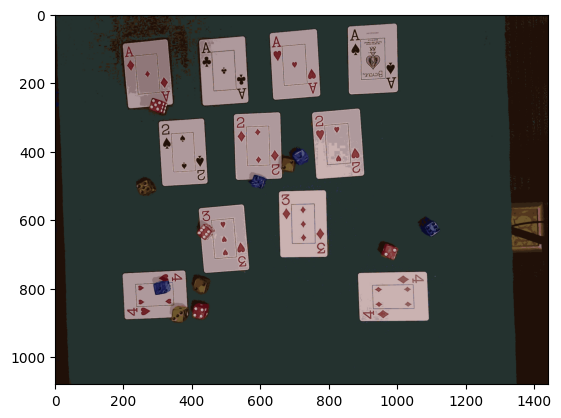

In [23]:
# classify_dice.imshow(classify_dice.posterize(img[None,:,:,:], k_means, palette))
# classify_dice.imshow()

_,pst = classify_dice.posterize(img[None,:,:,:], k_means, palette)
print(f"{pst.shape=}")
classify_dice.imshow(pst[0,:,:,:])


[[     1.7024    -0.76069]
 [   0.076792      1.2331]
 [   -0.13109      3.5818]
 [     1.1676    -0.29937]
 [   -0.21941      1.2047]
 [    -1.4118     -1.0786]
 [    -1.1512     -1.1423]
 [    -1.2243    -0.61473]
 [    0.61957     0.12576]
 [   0.016365      1.3512]
 [    0.12316      0.9662]
 [  -0.084335      2.4176]
 [      1.964    -0.87886]
 [  -0.082901      2.5405]
 [    0.32832    -0.19314]
 [    -1.1894    -0.77355]]


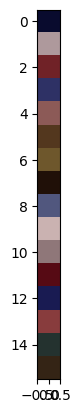

In [24]:
print(pca.transform(np.eye(16)))
classify_dice.imshow(einops.rearrange(palette, "N C -> N 1 C"))

In [25]:
for idx in range(10):
    print(idx)
    cap = cv2.VideoCapture(idx)
    if cap.isOpened():
        print(idx, 'open')
    cap.release()
cv2.destroyAllWindows()

cap = cv2.VideoCapture(2)
img = cap.read()[1]
cap.release()
classify_dice.imshow(res[1])
# res[1]

0
1
2
3
4
5
6
7
8
9


[ WARN:0@20.324] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ERROR:0@20.330] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@20.331] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video1): can't open camera by index
[ERROR:0@20.331] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@20.331] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video2): can't open camera by index
[ERROR:0@20.332] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@20.332] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video3): can't open camera by index
[ERROR:0@20.332] global obsensor_uvc_stream_channel.cpp:163 getStreamChannelGroup Camera index out of range
[ WARN:0@20.332] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video4): can't open camera by index
[ERROR:0@20.332] global obsensor_uvc_stream_channel.cpp:163 getStreamChan

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [ ]:

img_all = cv2.imread("data/misc/all.jpg")[None,:,:,:]
# img_all = cv2.imread("data/frames/frame_0214.jpg")[None,:,:,:]
img_colors = [
    # cv2.imread("data/frames/frame_0214.jpg")[None,:,:,:],
    # cv2.imread("data/frames/frame_0214.jpg")[None,:,:,:],
    # cv2.imread("data/frames/frame_0214.jpg")[None,:,:,:],
    cv2.imread("data/misc/red.jpg")[None,:,:,:],
    cv2.imread("data/misc/yellow.jpg")[None,:,:,:],
    cv2.imread("data/misc/purple.jpg")[None,:,:,:],
]

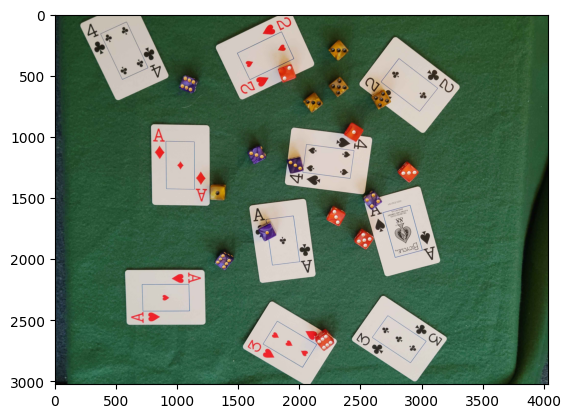

In [ ]:
classify_dice.show_imgs_grid(img_all,width=1)

Learning color palette from unsupervised dice img(s)...

0: 384x512 20 dies, 1 ace, 4 twos, 6 fours, 5.7ms
Speed: 1.1ms preprocess, 5.7ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 512)


Clustering to obtain player assignments...

0: 384x512 8 dies, 5 aces, 1 two, 3 fours, 6.6ms
Speed: 1.4ms preprocess, 6.6ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 512)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(8, 16384)
ligma.shape=(16,)

0: 384x512 9 dies, 1 ace, 4 twos, 1 three, 7 fours, 5.4ms
Speed: 1.1ms preprocess, 5.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 512)
curr_classes_flattened.shape=(9, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(9, 16384)
ligma.shape=(16,)
curr_classes_flattened.shape=(9, 16384)
ligma.shape=(16,)
curr_classes_flatt

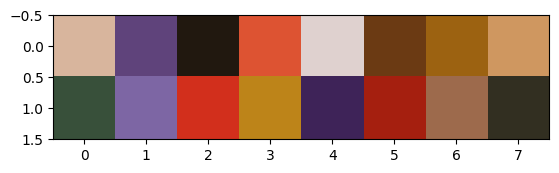

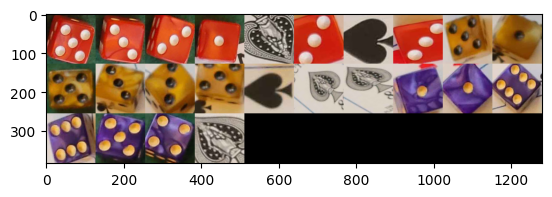

In [ ]:
import importlib
importlib.reload(classify_dice)
classify_dice.fit_player_colors(obb_model, img_all, img_colors)

In [45]:
print("jkl")

jkl
